[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]


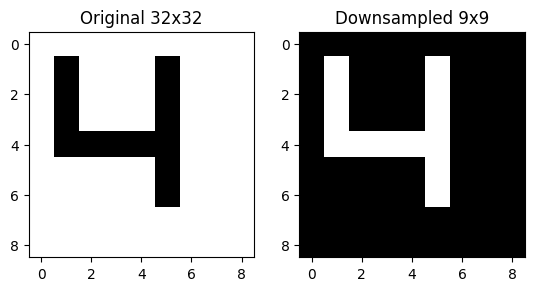

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (grayscale)
img = cv2.imread("new_4.png", cv2.IMREAD_GRAYSCALE)
inverted_img = 255 - img
inverted_img = inverted_img/255.0
# Normalize (0..1)
img = img / 255.0


# Resize to 9x9
img9 = cv2.resize(inverted_img, (9,9), interpolation=cv2.INTER_AREA)

print(img9)

plt.subplot(1,2,1)
plt.title("Original 32x32")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Downsampled 9x9")
plt.imshow(img9, cmap='gray')
plt.show()


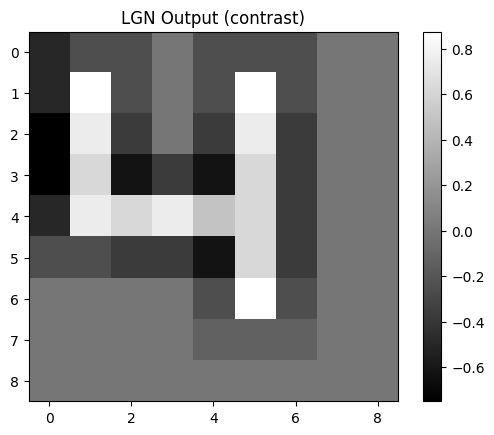

In [3]:


lgn_kernel = np.array([
    [-1/8, -1/8, -1/8],
    [-1/8,  1.0, -1/8],
    [-1/8, -1/8, -1/8]
])

lgn = cv2.filter2D(img9, -1, lgn_kernel)

plt.imshow(lgn, cmap='gray')
plt.colorbar()
plt.title("LGN Output (contrast)")
plt.show()


(Text(0.5, 1.0, 'Sobel Y'), ([], []), ([], []))

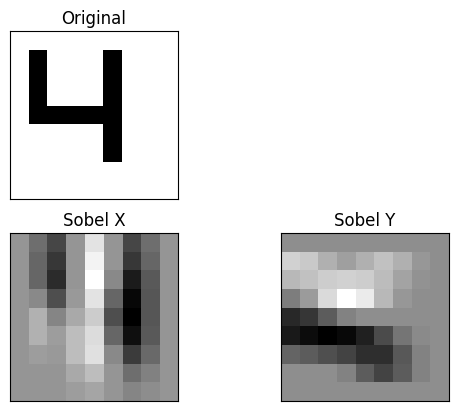

In [7]:
sobelx = cv2.Sobel(img9,cv2.CV_64F,1,0,ksize=5)
sobely = cv2.Sobel(img9,cv2.CV_64F,0,1,ksize=5)
 
plt.subplot(2,2,1),plt.imshow(img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
# plt.subplot(2,2,2),plt.imshow(laplacian,cmap = 'gray')
# plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,3),plt.imshow(sobelx,cmap = 'gray')
plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,4),plt.imshow(sobely,cmap = 'gray')
plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])
 

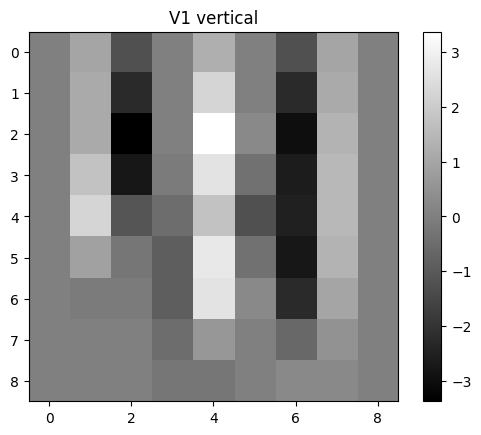

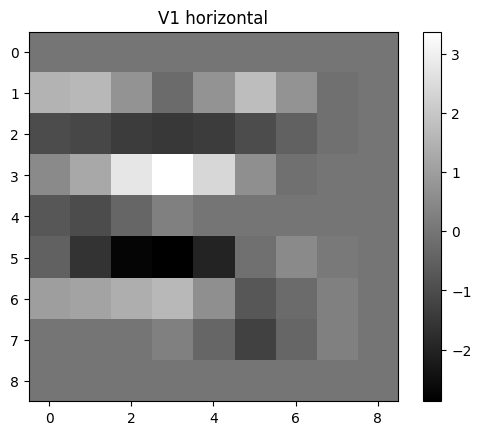

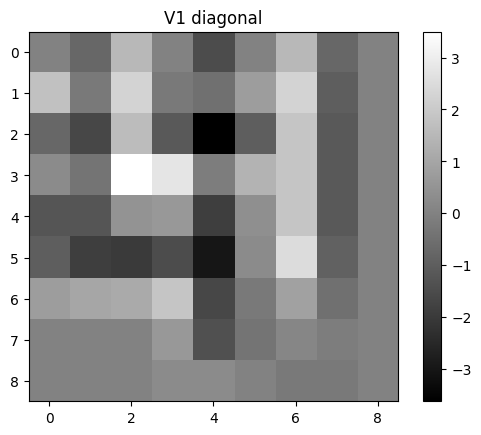

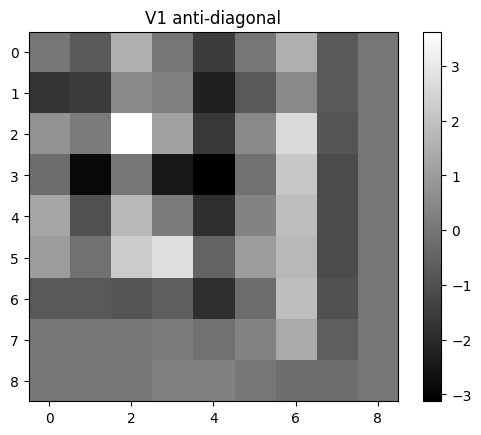

In [4]:
# Define 4 orientation filters (Sobel-like)
filters = {
    "vertical": np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
    "horizontal": np.array([[-1,-2,-1],[0,0,0],[1,2,1]]),
    "diagonal": np.array([[0,-1,-2],[1,0,-1],[2,1,0]]),
    "anti-diagonal": np.array([[2,1,0],[1,0,-1],[0,-1,-2]])
}

v1_maps = {}
for name, kernel in filters.items():
    v1_maps[name] = cv2.filter2D(lgn, -1, kernel)
    plt.imshow(v1_maps[name], cmap='gray')
    plt.colorbar()
    plt.title(f"V1 {name}")
    plt.show()


[[ 0.    1.   -1.25  0.    1.25  0.   -1.25  1.    0.  ]
 [ 1.5   2.75 -1.5  -0.25  3.    1.75 -1.5   1.    0.  ]
 [-1.    0.   -4.75 -1.5   2.   -0.75 -3.5   1.25  0.  ]
 [ 0.5   3.    0.    3.25  5.    0.25 -2.75  1.5   0.  ]
 [-0.75  1.25 -1.5  -0.25  1.75 -1.25 -2.5   1.5   0.  ]
 [-0.5  -0.75 -3.   -3.75  0.75 -0.5  -2.25  1.5   0.  ]
 [ 1.    1.    1.25  0.75  3.25 -0.5  -2.5   1.25  0.  ]
 [ 0.    0.    0.   -0.25  0.25 -1.25 -1.    0.75  0.  ]
 [ 0.    0.    0.   -0.25 -0.25  0.    0.25  0.25  0.  ]]


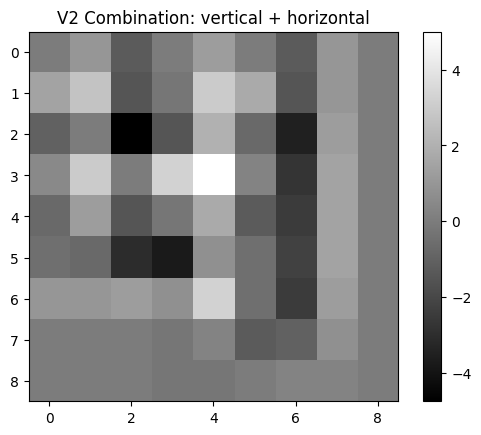

[[ 0.     0.25   0.25   0.    -0.25   0.     0.25   0.25   0.   ]
 [ 1.75   0.875  0.    -0.25   1.75   0.75   0.     0.125  0.   ]
 [-0.75  -0.5   -1.75  -1.125 -0.25  -0.75  -1.125  0.25   0.   ]
 [ 0.25   1.375  0.75   2.625  2.5    1.    -0.75   0.375  0.   ]
 [-1.25   1.    -0.625  0.125 -0.125 -0.875 -0.625  0.375  0.   ]
 [-1.    -1.    -2.25  -2.375 -0.25  -0.125 -0.25   0.5    0.   ]
 [ 0.75   0.875  1.     1.     1.     0.    -1.375  0.5    0.   ]
 [ 0.     0.     0.     0.125 -0.75  -0.375 -0.5    0.375  0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.   ]]


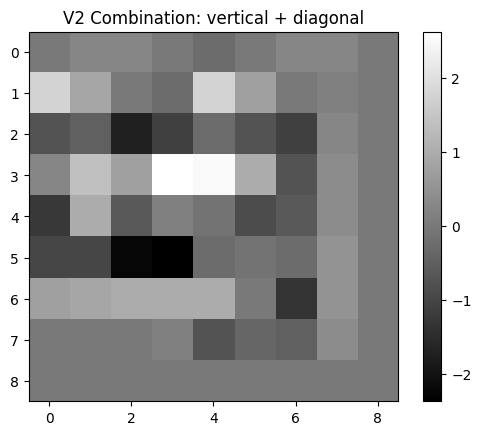

[[ 0.     0.25   0.25   0.    -0.25   0.     0.25   0.25   0.   ]
 [-1.75  -0.375 -1.75   0.25   0.    -0.75  -1.75   0.375  0.   ]
 [ 0.75   1.25   0.25   1.125  1.75   0.75  -0.375  0.5    0.   ]
 [-0.25  -1.125 -2.75  -2.625 -0.5   -0.5   -0.5    0.375  0.   ]
 [ 1.25   1.25   0.625 -0.375 -0.125 -0.875 -0.625  0.375  0.   ]
 [ 1.     0.75   2.     1.875  2.25   0.625 -1.     0.25   0.   ]
 [-0.75  -0.875 -1.    -1.5    0.75   0.    -0.375  0.     0.   ]
 [ 0.     0.     0.    -0.375  0.5    0.375  0.75  -0.125  0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.   ]]


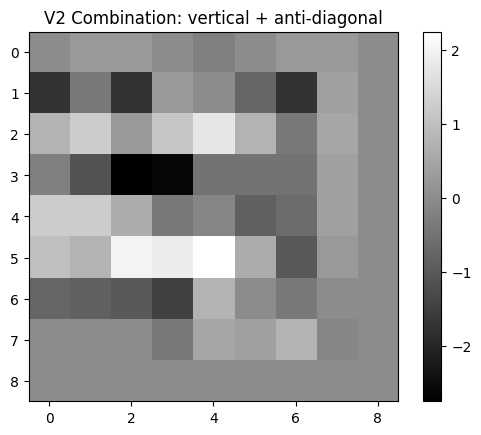

[[ 0.    -0.75   1.5    0.    -1.5    0.     1.5   -0.75   0.   ]
 [ 3.25   1.375  3.    -0.5    0.25   2.5    3.    -1.125  0.   ]
 [-1.75  -2.75   0.25  -2.625 -5.    -2.     1.375 -1.25   0.   ]
 [ 0.75   0.875  6.25   6.125  2.25   2.     1.75  -1.125  0.   ]
 [-2.    -2.25   0.125  0.875 -1.875  0.375  1.875 -1.125  0.   ]
 [-1.5   -3.5   -4.75  -4.375 -5.     0.125  3.    -0.75   0.   ]
 [ 1.75   2.125  2.5    3.5   -1.    -1.     0.625 -0.25   0.   ]
 [ 0.     0.     0.     0.875 -1.75  -1.625 -0.25   0.125  0.   ]
 [ 0.     0.     0.     0.25   0.25   0.    -0.25  -0.25   0.   ]]


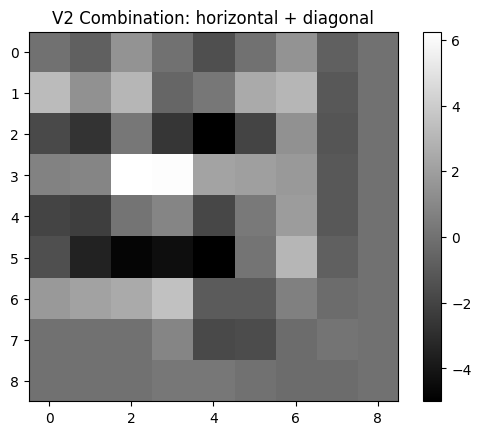

[[ 0.    -0.75   1.5    0.    -1.5    0.     1.5   -0.75   0.   ]
 [-0.25   0.125  1.25   0.    -1.5    1.     1.25  -0.875  0.   ]
 [-0.25  -1.     2.25  -0.375 -3.    -0.5    2.125 -1.     0.   ]
 [ 0.25  -1.625  2.75   0.875 -0.75   0.5    2.    -1.125  0.   ]
 [ 0.5   -2.     1.375  0.375 -1.875  0.375  1.875 -1.125  0.   ]
 [ 0.5   -1.75  -0.5   -0.125 -2.5    0.875  2.25  -1.     0.   ]
 [ 0.25   0.375  0.5    1.    -1.25  -1.     1.625 -0.75   0.   ]
 [ 0.     0.     0.     0.375 -0.5   -0.875  1.    -0.375  0.   ]
 [ 0.     0.     0.     0.25   0.25   0.    -0.25  -0.25   0.   ]]


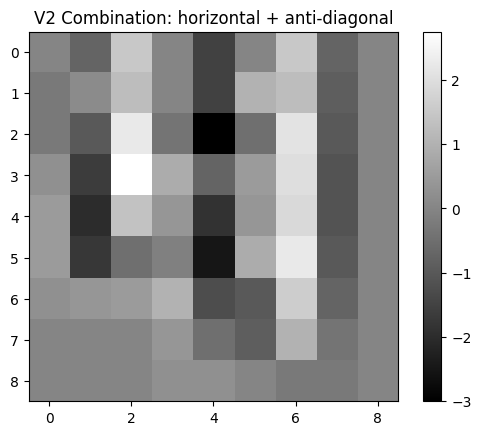

[[ 0.   -1.5   3.    0.   -3.    0.    3.   -1.5   0.  ]
 [ 0.   -1.75  2.75  0.   -2.75  0.    2.75 -1.75  0.  ]
 [ 0.   -1.5   5.25  0.   -5.25 -0.5   4.5  -2.    0.  ]
 [ 0.   -3.25  3.5   0.25 -3.25  1.25  4.   -2.25  0.  ]
 [ 0.   -2.25  2.25  0.75 -3.75  0.75  3.75 -2.25  0.  ]
 [ 0.   -2.    0.25  1.25 -3.5   1.25  4.25 -2.    0.  ]
 [ 0.    0.25  0.25  1.25 -3.5  -0.5   2.75 -1.5   0.  ]
 [ 0.    0.    0.    0.75 -1.5   0.    1.5  -0.75  0.  ]
 [ 0.    0.    0.    0.5   0.5   0.   -0.5  -0.5   0.  ]]


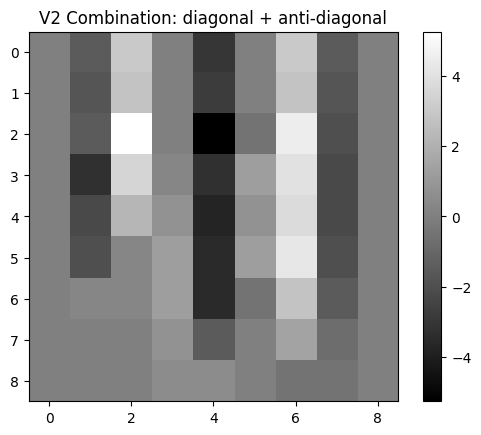

In [8]:
names = list(v1_maps.keys())
v2_maps = {}

for i in range(len(names)):
    for j in range(i+1, len(names)):
        combo_name = f"{names[i]} + {names[j]}"
        v2_maps[combo_name] = v1_maps[names[i]] + v1_maps[names[j]]
        print(v2_maps[combo_name])
        plt.imshow(v2_maps[combo_name],cmap='gray')
        plt.title(f"V2 Combination: {combo_name}")
        plt.colorbar()
        plt.show()

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
import cv2
from keras.datasets import mnist
import os

# ---------------- Data ----------------
def load_mnist_9x9():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train.astype(np.float32)/255.0
    x_test = x_test.astype(np.float32)/255.0

    def downsample(imgs):
        out = np.zeros((imgs.shape[0],9,9), dtype=np.float32)
        for i in range(imgs.shape[0]):
            out[i] = cv2.resize(imgs[i], (9,9), interpolation=cv2.INTER_AREA)
        return out

    x_train9 = downsample(x_train)
    x_test9 = downsample(x_test)
    return x_train9.reshape(-1,81), y_train, x_test9.reshape(-1,81), y_test

# ---------------- Model ----------------
def build_model():
    inp = keras.Input(shape=(81,), name="input")

    # LGN layer
    lgn = layers.Dense(81, activation="sigmoid", name="LGN")(inp)

    # V1 layer
    v1 = layers.Dense(81, activation="sigmoid", name="V1")(lgn)

    # V2 layer
    v2 = layers.Dense(81, activation="sigmoid", name="V2")(v1)

    out = layers.Dense(10, activation="softmax")(v2)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# ---------------- Train ----------------
if __name__ == "__main__":
    x_train, y_train, x_test, y_test = load_mnist_9x9()
    model = build_model()
    model.summary()

    history = model.fit(x_train, y_train, batch_size=128, epochs=10,
                        validation_split=0.1, verbose=1)

    loss, acc = model.evaluate(x_test, y_test, verbose=1)
    print("Test accuracy:", acc)

    os.makedirs("saved_models", exist_ok=True)
    model.save("saved_models/ann_lgn_v1_v2.keras")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 81)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LGN (Dense)                     │ (None, 81)             │         6,642 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ V1 (Dense)                      │ (None, 81)             │         6,642 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ V2 (Dense)                      │ (None, 81)             │         6,642 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,746 (81.04 KB)

 Trainable params: 20,746 (81.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4441 - loss: 1.7058 - val_accuracy: 0.7550 - val_loss: 0.8371
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7868 - loss: 0.7031 - val_accuracy: 0.8512 - val_loss: 0.5065
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8474 - loss: 0.5121 - val_accuracy: 0.8827 - val_loss: 0.3947
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8702 - loss: 0.4296 - val_accuracy: 0.9010 - val_loss: 0.3351
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8836 - loss: 0.3771 - val_accuracy: 0.9107 - val_loss: 0.2953
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8942 - loss: 0.3421 - val_accuracy: 0.9198 - val_loss: 0.2712
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9016 - loss: 0.3167 - val_accuracy: 0.9258 - val_loss: 0.2513
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9081 - loss: 0.2957 - val_accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted digit: 3
Probabilities: [[3.1133103e-03 3.3067788e-03 4.7307238e-03 7.2717828e-01 1.3850618e-05
  2.5614047e-01 1.8916084e-05 2.8072300e-03 1.4484433e-03 1.2420340e-03]]


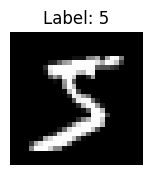

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted digit: 0
Probabilities: [[9.9754190e-01 1.8803249e-07 6.8649941e-04 9.7858901e-05 9.0642943e-06
  9.1867539e-04 6.6851688e-05 2.2938091e-04 6.6185762e-06 4.4294278e-04]]


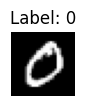

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted digit: 4
Probabilities: [[2.0856672e-04 1.7209904e-05 1.1641680e-03 1.9894858e-04 9.6309817e-01
  7.4599922e-04 6.0482213e-04 2.4399136e-03 3.9452931e-04 3.1127688e-02]]


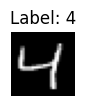

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted digit: 1
Probabilities: [[3.0828659e-07 9.8916245e-01 3.1955179e-03 6.3026580e-04 1.4253367e-04
  5.2545161e-04 1.6707811e-04 3.0701717e-03 3.0356017e-03 7.0674170e-05]]


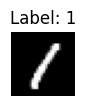

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted digit: 9
Probabilities: [[2.5990657e-06 8.9920912e-05 9.3076296e-06 1.4264690e-04 6.2640798e-03
  9.7633725e-05 3.6250376e-07 2.7621540e-03 3.9687374e-04 9.9023438e-01]]


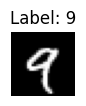

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted digit: 2
Probabilities: [[6.9600162e-03 5.2118913e-04 8.6603153e-01 6.9285475e-02 1.5871075e-04
  2.8856046e-04 2.1987875e-05 1.0782351e-02 4.3745812e-02 2.2043940e-03]]


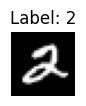

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted digit: 1
Probabilities: [[1.6181369e-08 9.9750656e-01 2.2945547e-04 1.3012575e-03 2.4144929e-05
  1.4524501e-04 2.8479295e-05 1.7529406e-04 5.6934118e-04 2.0356807e-05]]


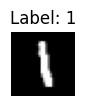

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted digit: 3
Probabilities: [[2.6140644e-04 2.5708339e-04 9.9614784e-03 9.7787285e-01 1.0844342e-05
  4.1441544e-04 4.0025478e-07 8.0907531e-04 9.4949119e-03 9.1748958e-04]]


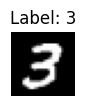

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted digit: 1
Probabilities: [[4.3684086e-08 9.9769789e-01 8.0301179e-05 4.6333208e-04 8.7786604e-05
  6.3178845e-04 4.8525188e-05 5.4457155e-04 3.4977609e-04 9.6024189e-05]]


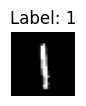

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted digit: 4
Probabilities: [[5.2427007e-05 3.7116875e-05 7.0414133e-04 1.9987796e-05 9.8940873e-01
  1.9402188e-03 5.2356990e-03 4.3908614e-04 3.1350969e-04 1.8490705e-03]]


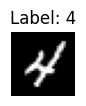

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted digit: 3
Probabilities: [[1.1869061e-05 7.8721828e-04 7.5974670e-04 9.9502677e-01 2.6826854e-06
  4.1192822e-04 2.4357956e-07 1.3513016e-04 2.6470846e-03 2.1733277e-04]]


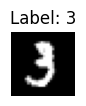

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted digit: 5
Probabilities: [[3.3789598e-05 8.5735537e-02 7.6971017e-04 9.0788485e-04 2.5950518e-04
  8.7282550e-01 2.0237932e-02 1.8177992e-04 1.9007113e-02 4.1272393e-05]]


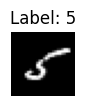

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted digit: 3
Probabilities: [[4.1640528e-06 2.9876761e-04 4.3095832e-04 9.9883550e-01 3.6260008e-07
  1.2430530e-04 6.0335793e-08 8.9155270e-05 1.8773193e-04 2.8976818e-05]]


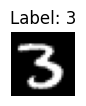

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted digit: 6
Probabilities: [[1.4607408e-04 1.9594792e-05 2.0598597e-03 3.6161782e-06 1.0971715e-03
  1.3996936e-04 9.9636298e-01 3.1598429e-06 1.6520554e-04 2.4104568e-06]]


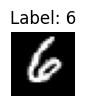

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted digit: 1
Probabilities: [[3.17404307e-08 9.98264015e-01 8.73462486e-05 1.92633015e-04
  3.89717861e-05 7.22646771e-04 1.12945425e-04 1.83943775e-04
  3.76009557e-04 2.14393967e-05]]


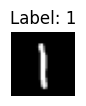

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted digit: 7
Probabilities: [[2.1136297e-05 1.9442965e-05 1.4523924e-05 1.3466159e-04 6.4328269e-05
  2.2125598e-04 1.4983197e-08 9.5946443e-01 1.0309381e-05 4.0050022e-02]]


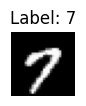

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted digit: 2
Probabilities: [[1.1152050e-03 1.1584432e-04 9.8594296e-01 2.3318622e-03 4.8499893e-05
  5.4394727e-06 2.5477195e-05 1.0191191e-02 1.9025672e-04 3.3165968e-05]]


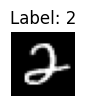

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted digit: 8
Probabilities: [[1.2646040e-05 5.2483737e-02 1.8033562e-03 4.1931323e-03 1.6758564e-03
  3.4676550e-03 3.7068854e-05 2.8636078e-03 9.0822464e-01 2.5238199e-02]]


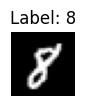

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted digit: 6
Probabilities: [[2.7615302e-03 7.4457680e-04 4.0369672e-03 8.3726761e-04 7.3649297e-03
  1.1407914e-01 8.5834867e-01 3.8159018e-05 1.1521772e-02 2.6705180e-04]]


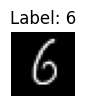

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted digit: 9
Probabilities: [[3.1077295e-06 1.5799219e-02 9.2607414e-05 1.3079515e-02 6.5128608e-03
  5.7977182e-04 4.5380901e-07 8.0065034e-02 1.6545878e-03 8.8221294e-01]]


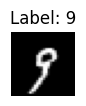

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted digit: 4
Probabilities: [[4.00952558e-05 1.77926686e-05 1.39612472e-03 1.20069322e-04
  9.86283541e-01 1.47314306e-04 7.46504578e-04 4.92387509e-04
  4.83493321e-04 1.02726165e-02]]


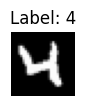

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted digit: 0
Probabilities: [[9.9590331e-01 4.8584099e-07 9.6018118e-04 2.5140701e-04 8.6066048e-06
  1.8806276e-03 6.4461390e-05 4.0910565e-04 8.4108742e-06 5.1346561e-04]]


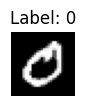

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted digit: 9
Probabilities: [[4.1906766e-05 4.9026920e-03 1.8648690e-03 2.0806489e-03 1.3106731e-01
  1.1960358e-03 3.8723945e-05 1.6266793e-01 2.4727716e-03 6.9366705e-01]]


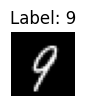

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted digit: 1
Probabilities: [[2.0660319e-07 9.8462766e-01 2.8374307e-03 7.4298721e-04 2.4079969e-04
  2.2681200e-04 5.1772291e-05 9.3406346e-03 1.7465886e-03 1.8524431e-04]]


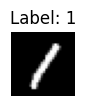

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted digit: 5
Probabilities: [[2.4365888e-03 3.3810239e-02 1.4173520e-02 1.4261387e-01 1.7757101e-04
  7.8725237e-01 5.8808462e-03 6.5266155e-04 1.2618183e-02 3.8416657e-04]]


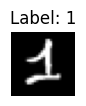

In [10]:
import cv2
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.datasets import mnist

# load trained model
model = keras.models.load_model("saved_models/ann_lgn_v1_v2.keras")

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display the first few training images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

    # Downsample and reshape the image for prediction
    img_9x9 = cv2.resize(x_train[i], (9,9), interpolation=cv2.INTER_AREA)
    img_9x9_flat = img_9x9.reshape(1, 81).astype(np.float32) / 255.0 # Normalize to 0-1

    probs = model.predict(img_9x9_flat)
    pred = np.argmax(probs, axis=1)[0]
    print("Predicted digit:", pred)
    print("Probabilities:", probs)
    plt.show()
# predict

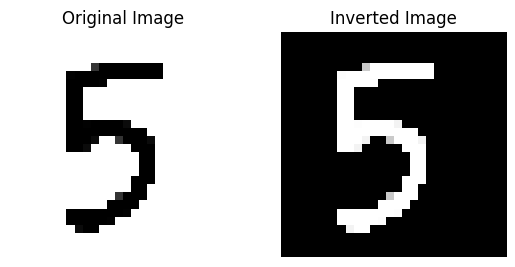

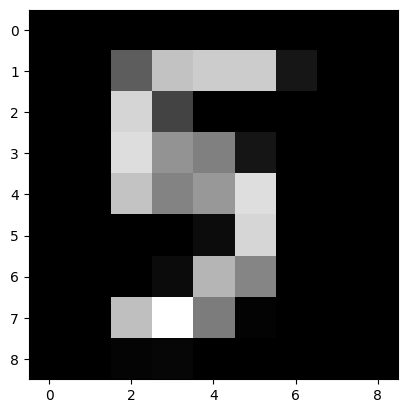

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted digit: 5
Probabilities: [[1.7368493e-03 1.7461085e-03 2.2497650e-03 8.2216531e-02 1.0628955e-02
  8.0463982e-01 6.7878403e-03 2.7703223e-04 7.9530984e-02 1.0186112e-02]]


In [14]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)

# Invert the image
inverted_img = 255 - img

# Display the original and inverted images
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(inverted_img, cmap='gray')
plt.title("Inverted Image")
plt.axis('off')

plt.show()

img_9x9 = cv2.resize(inverted_img, (9,9), interpolation=cv2.INTER_AREA)
plt.imshow(img_9x9, cmap='gray')
plt.show()
img_9x9_flat = img_9x9.reshape(1, 81).astype(np.float32) / 255.0 # Normalize to 0-1

probs = model.predict(img_9x9_flat)
pred = np.argmax(probs, axis=1)[0]
print("Predicted digit:", pred)
print("Probabilities:", probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


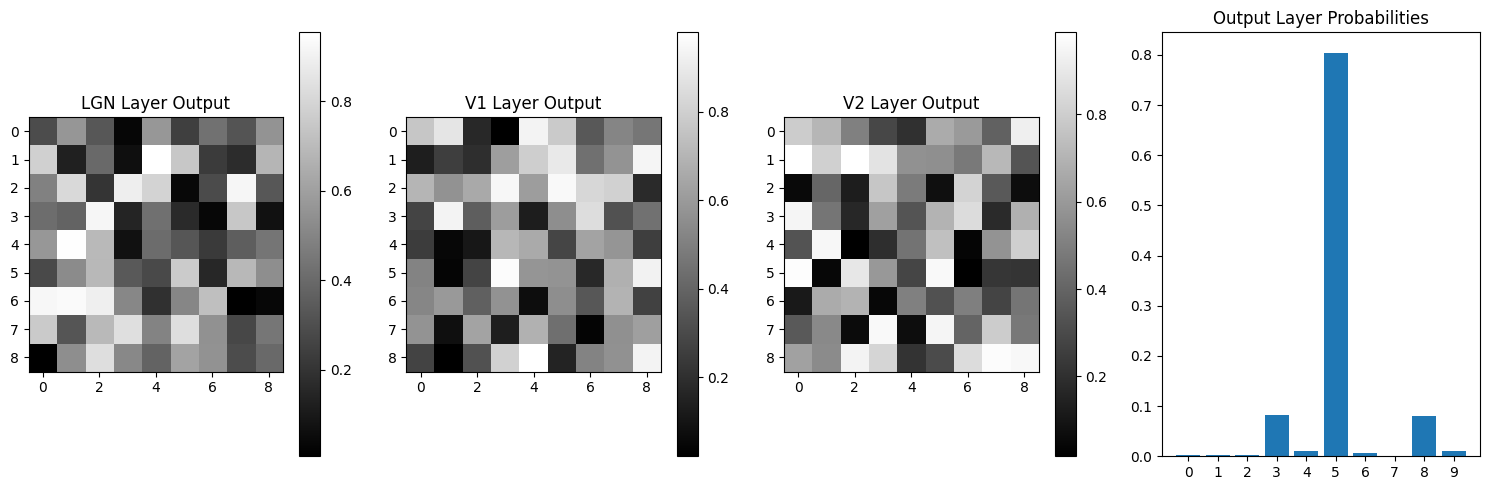

In [16]:
from tensorflow import keras

model = keras.models.load_model("saved_models/ann_lgn_v1_v2.keras")
# Create models to output the activations of each layer
lgn_model = keras.Model(inputs=model.input, outputs=model.get_layer("LGN").output)
v1_model = keras.Model(inputs=model.input, outputs=model.get_layer("V1").output)
v2_model = keras.Model(inputs=model.input, outputs=model.get_layer("V2").output)
output_model = keras.Model(inputs=model.input, outputs=model.get_layer("dense").output)

# Get the outputs of each layer for the sample image
lgn_output = lgn_model.predict(img_9x9_flat)
v1_output = v1_model.predict(img_9x9_flat)
v2_output = v2_model.predict(img_9x9_flat)
output = output_model.predict(img_9x9_flat)

# Reshape the outputs to 9x9 for visualization
lgn_output_reshaped = lgn_output.reshape(9, 9)
v1_output_reshaped = v1_output.reshape(9, 9)
v2_output_reshaped = v2_output.reshape(9, 9)

# Display the output of each layer
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(lgn_output_reshaped, cmap='gray')
plt.title("LGN Layer Output")
plt.colorbar()

plt.subplot(1, 4, 2)
plt.imshow(v1_output_reshaped, cmap='gray')
plt.title("V1 Layer Output")
plt.colorbar()

plt.subplot(1, 4, 3)
plt.imshow(v2_output_reshaped, cmap='gray')
plt.title("V2 Layer Output")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.bar(range(10), output[0])
plt.xticks(range(10))
plt.title("Output Layer Probabilities")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


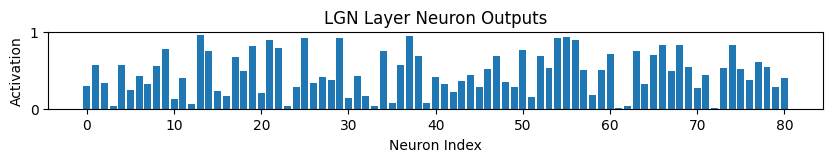

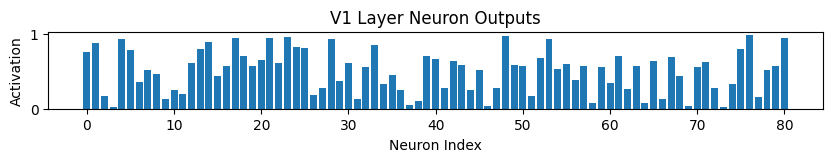

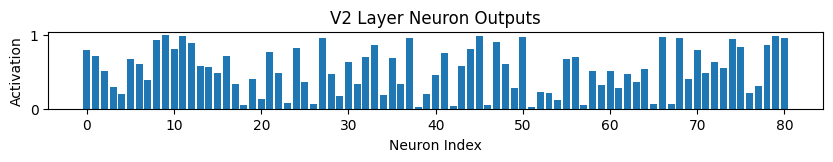

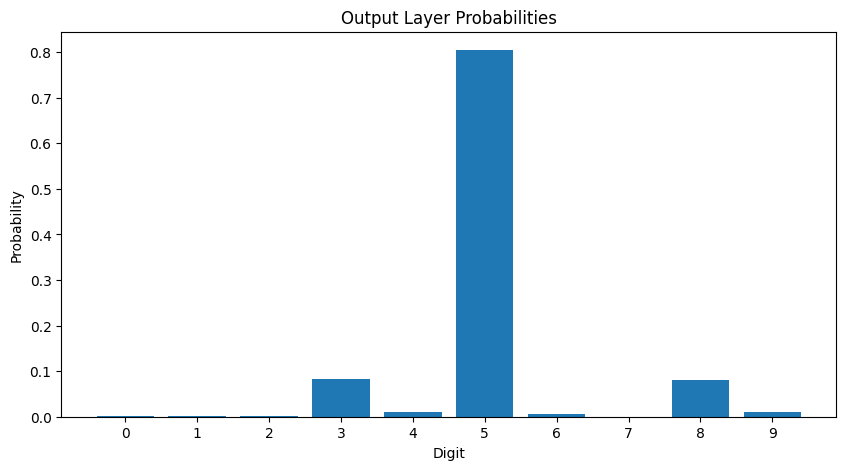

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Get the outputs of each layer for the sample image
lgn_output = lgn_model.predict(img_9x9_flat)[0]
v1_output = v1_model.predict(img_9x9_flat)[0]
v2_output = v2_model.predict(img_9x9_flat)[0]
output = output_model.predict(img_9x9_flat)[0]

# Function to plot neuron outputs
def plot_neuron_outputs(outputs, title):
    plt.figure(figsize=(10, 1))
    plt.bar(range(len(outputs)), outputs)
    plt.title(title)
    plt.xlabel("Neuron Index")
    plt.ylabel("Activation")
    plt.show()

# Plot outputs for each layer
plot_neuron_outputs(lgn_output, "LGN Layer Neuron Outputs")
plot_neuron_outputs(v1_output, "V1 Layer Neuron Outputs")
plot_neuron_outputs(v2_output, "V2 Layer Neuron Outputs")


# Plot output layer probabilities
plt.figure(figsize=(10, 5))
plt.bar(range(10), output)
plt.xticks(range(10))
plt.title("Output Layer Probabilities")
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.show()